# 04 — DistilBERT


In [1]:
# project setup
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/voxforge-ai-review-analytics"
).resolve()

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(
        f"Could not find src/ inside {PROJECT_ROOT}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%cd /content/voxforge-ai-review-analytics

print("Project root:", PROJECT_ROOT)

/content/voxforge-ai-review-analytics
Project root: /content/voxforge-ai-review-analytics


In [2]:
%pip install -q -r requirements.txt
%pip install -q -e .

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for voxforge (pyproject.toml) ... done


In [3]:
# verify the runtime
import sys
from pathlib import Path

print("Python:", sys.executable)
print("Current directory:", Path.cwd())
print("src exists:", Path("src").exists())
print("Project files:", list(Path.cwd().iterdir())[:10])

Python: /usr/bin/python3
Current directory: /content/voxforge-ai-review-analytics
src exists: True
Project files: [PosixPath('/content/voxforge-ai-review-analytics/artifacts'), PosixPath('/content/voxforge-ai-review-analytics/.git'), PosixPath('/content/voxforge-ai-review-analytics/data'), PosixPath('/content/voxforge-ai-review-analytics/requirements.txt'), PosixPath('/content/voxforge-ai-review-analytics/notebooks'), PosixPath('/content/voxforge-ai-review-analytics/docs'), PosixPath('/content/voxforge-ai-review-analytics/pyproject.toml'), PosixPath('/content/voxforge-ai-review-analytics/backend'), PosixPath('/content/voxforge-ai-review-analytics/models'), PosixPath('/content/voxforge-ai-review-analytics/README.md')]


In [4]:
# connect google drive
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# copy the dataset from google drive
from pathlib import Path
import shutil

PROJECT_ROOT = Path("/content/voxforge-ai-review-analytics")

DRIVE_DATASET_PATH = Path(
    "/content/drive/MyDrive/VoxForge/data/processed/cleaned_reviews.csv"
)

PROJECT_DATASET_PATH = (
    PROJECT_ROOT / "data" / "processed" / "cleaned_reviews.csv"
)

PROJECT_DATASET_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if not DRIVE_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found in Google Drive: {DRIVE_DATASET_PATH}"
    )

shutil.copy2(
    DRIVE_DATASET_PATH,
    PROJECT_DATASET_PATH,
)

print("Dataset copied successfully.")
print("Source:", DRIVE_DATASET_PATH)
print("Destination:", PROJECT_DATASET_PATH)
print("Exists:", PROJECT_DATASET_PATH.exists())

Dataset copied successfully.
Source: /content/drive/MyDrive/VoxForge/data/processed/cleaned_reviews.csv
Destination: /content/voxforge-ai-review-analytics/data/processed/cleaned_reviews.csv
Exists: True


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

from src.config import *
from src.data.load import load_csv
from src.config import (
    CLEANED_REVIEWS_PATH,
    DISTILBERT_MODEL_DIR,
    DISTILBERT_PREDICTIONS_PATH,
    DISTILBERT_CONFUSION_MATRIX_PATH,
    DISTILBERT_CONFUSION_MATRIX_CSV_PATH,
    DISTILBERT_CLASSIFICATION_REPORT_PATH,
    DISTILBERT_TRAINING_HISTORY_PATH,
    SENTIMENT_LABELS,
)

from src.sentiment.transformer import (
    TransformerExperimentConfig,
    evaluate_trained_transformer,
    plot_training_history,
    prepare_transformer_sentiment_data,
    save_transformer_artifact,
    save_transformer_evaluation_artifacts,
    train_transformer,
)
from src.tracker import log_experiment

create_project_directories()
print("Runtime device:", runtime_device())

ImportError: cannot import name 'DISTILBERT_CLASSIFICATION_REPORT_PATH' from 'src.config' (/content/voxforge-ai-review-analytics/src/config.py)

In [ ]:
# model constants
MODEL_DIR = SENTIMENT_MODELS_DIR / "distilbert_sentiment"
CONFUSION_PATH = CONFUSION_MATRICES_DIR / "distilbert_sentiment.png"
HISTORY_PATH = PLOTS_DIR / "distilbert_sentiment_training_history.png"
PREDICTIONS_PATH = PREDICTIONS_DIR / "distilbert_sentiment_validation.csv"

In [ ]:
# Load the cleaned dataset
print("Configured path:", CLEANED_REVIEWS_PATH)
print("Exists:", CLEANED_REVIEWS_PATH.exists())

reviews = load_csv(CLEANED_REVIEWS_PATH)
model_df = prepare_transformer_sentiment_data(reviews)

Configured path: /content/voxforge-ai-review-analytics/data/processed/cleaned_reviews.csv
Exists: True


In [ ]:
#  split the cleaned dataset
X_train_val, X_test, y_train_val, y_test = train_test_split(
    model_df["transformer_text"], model_df["sentiment_label"],
    test_size=0.20, random_state=RANDOM_STATE, stratify=model_df["sentiment_label"],
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_val,
)
print(f"Train: {len(X_train):,} | Validation: {len(X_val):,} | Test held out: {len(X_test):,}")

Train: 30,258 | Validation: 7,565 | Test held out: 9,456


In [ ]:
# configure and train
config = TransformerExperimentConfig(
    model_id="sentiment_02",
    model_name="DistilBERT",
    pretrained_model="distilbert-base-uncased",
    output_dir=MODEL_DIR,
    max_length=256,
    epochs=3,
    train_batch_size=16,
    eval_batch_size=32,
    learning_rate=2e-5,
    gradient_accumulation_steps=1,
    use_lora=False,
    use_4bit=False,
    lora_r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    lora_target_modules=("q_lin", "v_lin"),
)
config

TransformerExperimentConfig(model_id='sentiment_02', model_name='DistilBERT', pretrained_model='distilbert-base-uncased', output_dir=PosixPath('/content/voxforge-ai-review-analytics/models/sentiment/distilbert_sentiment'), max_length=256, epochs=3, train_batch_size=16, eval_batch_size=32, learning_rate=2e-05, weight_decay=0.01, warmup_ratio=0.1, gradient_accumulation_steps=1, use_lora=False, use_4bit=False, lora_r=16, lora_alpha=32, lora_dropout=0.1, lora_target_modules=('q_lin', 'v_lin'), random_state=42, early_stopping_patience=2)

In [ ]:
run = train_transformer(
    config, X_train, y_train, X_val, y_val
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.617226,0.897077,0.946200,0.721117,0.733962,0.717341,0.943993
2,0.506945,0.718253,0.947786,0.743891,0.738163,0.740912,0.947891
3,0.344894,0.978458,0.950826,0.767735,0.739835,0.752783,0.950578


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

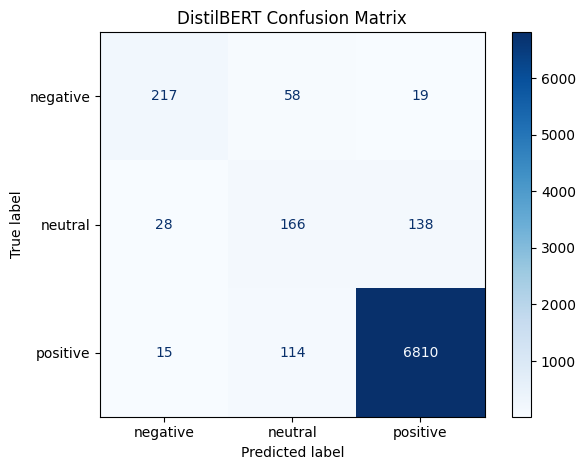

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,0.950826,0.767735,0.739835,0.752783,0.950578


,precision,recall,f1-score,support
negative,0.834615,0.738095,0.783394,294.000000
neutral,0.491124,0.500000,0.495522,332.000000
positive,0.977465,0.981409,0.979433,6939.000000
accuracy,0.950826,0.950826,0.950826,0.950826
macro avg,0.767735,0.739835,0.752783,7565.000000
weighted avg,0.950570,0.950826,0.950578,7565.000000


In [ ]:
# Evaluate and save useful outputs
validation = evaluate_trained_transformer(
    run=run,
    X=X_val,
    y_true=y_val,
    confusion_matrix_path=DISTILBERT_CONFUSION_MATRIX_PATH,
)

validation["metrics"]
display(pd.DataFrame([validation["metrics"]]))
display(validation["classification_report"])

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

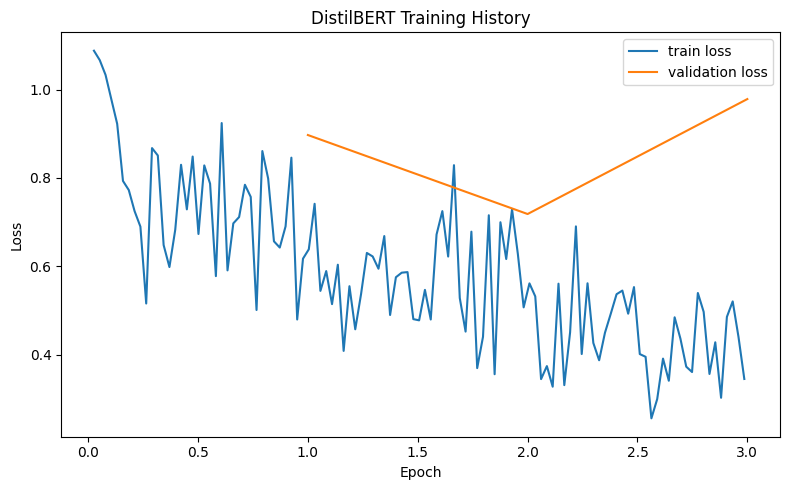

Model: /content/voxforge-ai-review-analytics/models/sentiment/distilbert_sentiment
Predictions: /content/voxforge-ai-review-analytics/results/predictions/distilbert_validation_predictions.csv
Training plot: /content/voxforge-ai-review-analytics/results/plots/distilbert_sentiment_training_history.png
Confusion matrix: /content/voxforge-ai-review-analytics/results/confusion_matrices


In [ ]:
# Save trained model
saved_model = save_transformer_artifact(
    run,
    DISTILBERT_MODEL_DIR,
)

# Save evaluation artifacts
saved_outputs = save_transformer_evaluation_artifacts(
    X=X_val,
    y_true=y_val,
    evaluation=validation,
    predictions_path=DISTILBERT_PREDICTIONS_PATH,
    classification_report_path=DISTILBERT_CLASSIFICATION_REPORT_PATH,
    confusion_matrix_csv_path=DISTILBERT_CONFUSION_MATRIX_CSV_PATH,
)

# Save training history
saved_history = plot_training_history(
    run,
    DISTILBERT_TRAINING_HISTORY_PATH,
)

print(f"Model: {saved_model}")
print(f"Predictions: {saved_outputs['predictions']}")
print(f"Classification report: {saved_outputs['classification_report']}")
print(f"Confusion matrix CSV: {saved_outputs['confusion_matrix_csv']}")
print(f"Confusion matrix PNG: {DISTILBERT_CONFUSION_MATRIX_PATH}")
print(f"Training history: {saved_history}")

In [ ]:
# Update the shared model tracker
tracking = log_experiment(
    model_id=config.model_id,
    model_name=config.model_name,
    model_family="Transformer",
    features="Contextual token embeddings",
    preprocessing="transformer_text; tokenizer truncation and dynamic padding",
    algorithm="Full fine-tuning",
    pretrained_model=config.pretrained_model,
    dataset=CLEANED_REVIEWS_PATH.name,
    training_rows=len(X_train),
    validation_rows=len(X_val),
    metrics=validation["metrics"],
    training_time_seconds=run["training_time_seconds"],
    inference_time_ms=validation["inference"]["average_inference_ms"],
    epochs=config.epochs,
    batch_size=config.train_batch_size,
    learning_rate=config.learning_rate,
    max_length=config.max_length,
    artifact_path=saved_model,
    hyperparameters={**config.to_dict(), "using_4bit": run["using_4bit"]},
    output_file=MODEL_TRACKING_PATH,
)
display(tracking)

/content/voxforge-ai-review-analytics/src/tracker.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tracking = pd.concat([existing, new_row], ignore_index=True, sort=False)


,timestamp_utc,model_id,model_name,model_family,features,preprocessing,algorithm,dataset,training_rows,validation_rows,...,training_time_seconds,inference_time_ms,artifact_path,hyperparameters,pretrained_model,validation_accuracy,epochs,batch_size,learning_rate,max_length
0,2026-07-22T03:03:24+00:00,sentiment_01,tfidf_logistic_regression,Classical ML,TF-IDF unigrams and bigrams,classical_text,Logistic Regression,cleaned_reviews.csv,30256,7564,...,3.438445,0.027363,/Users/karima/Ironhack-challenges/voxforge-ai-...,"{""memory"": null, ""steps"": [[""tfidf"", {""analyze...",NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-22T12:34:54+00:00,sentiment_02,DistilBERT,Transformer,Contextual token embeddings,transformer_text; tokenizer truncation and dyn...,Full fine-tuning,cleaned_reviews.csv,30258,7565,...,1576.140741,6.499540,/content/voxforge-ai-review-analytics/models/s...,"{""early_stopping_patience"": 2, ""epochs"": 3, ""e...",distilbert-base-uncased,0.950826,3.0,16.0,0.00002,256.0


The test split remains untouched. Use it only once after selecting the final model from validation metrics.